In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mplcursors

pd.set_option('display.max_columns', None)

df = pd.read_csv("house_data.csv")

Our result house_data.csv is a inner join result of the tables "king_county_house_details" and "king_county_house_sales"

The following columns not needed anymore were already deleated:
- house_id
- lat
- long

Filling missing column values

In [2]:
# Filling all NaN values with 0 under the assumption that NaN means no waterfront
df['waterfront'] = df.waterfront.fillna(0.0)

def strip_year_over_4_char(input: str):
    if len(input) > 4:
        return input[0:4]

# Strip unnecessay 0.0 from year (e.g 19910.0) in year_renovated and filling nan with 0 under the assumption that NaN means no renovation
df['yr_renovated'] = df.yr_renovated.astype(str)
df['yr_renovated'] = df.yr_renovated.apply(strip_year_over_4_char)
df['yr_renovated'] = df.yr_renovated.fillna(0)
df['yr_renovated'] = df.yr_renovated.astype(int)

# Filling NaN in view with mode (0)
df['view'] = df.view.fillna(0.0)

#df.head(20)

# Filling sqft_basement values by 0
df.sqft_basement = df.sqft_basement.fillna(0)
df.sqft_basement.value_counts(dropna=False)

sqft_basement
0.0       13279
600.0       217
700.0       209
500.0       209
800.0       201
          ...  
1920.0        1
3480.0        1
2730.0        1
2720.0        1
248.0         1
Name: count, Length: 303, dtype: int64

The following column types need to be converted:
- bedrooms from float to int
- bathrooms from float to int
- floors from float to int
- waterfront from float to int
- view from float to int
-  sell_date from str to datetime     

In [3]:
df.bedrooms = df.bedrooms.astype(int)
df.bathrooms = df.bathrooms.astype(int)
df.floors = df.floors.astype(int)
df.waterfront = df.waterfront.astype(int)
df.view = df.view.astype(int)
df["view"] = df["view"].astype(int)
df.sell_date = pd.to_datetime(df.sell_date)
# 2.5.2014 -> 27.5.2015

Check duplicates in dataframe

In [4]:
# No further action needed because of no duplicates
df.duplicated().value_counts()

False    21597
Name: count, dtype: int64

Data cleaning

In [5]:
df.head(100)

# No further action needed because of no data that is out of the ordinary
df.house_id.value_counts()
df.bedrooms.value_counts()
df.bathrooms.value_counts()
df.sqft_living.value_counts()
df.sqft_lot.value_counts()
df.floors.value_counts()
df.waterfront.value_counts()
df.view.value_counts()
df.condition.value_counts()
df.grade.value_counts()
df.sqft_above.value_counts()
df.sqft_basement.value_counts()
df.yr_built.value_counts()
df.yr_renovated.value_counts()
df.zipcode.value_counts()
df.lat.value_counts()
df.long.value_counts()
df.sqft_living15.value_counts()
df.sqft_lot15.value_counts()
df.sell_date.value_counts()
df.sell_price.value_counts()

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   house_id       21597 non-null  int64         
 1   bedrooms       21597 non-null  int64         
 2   bathrooms      21597 non-null  int64         
 3   sqft_living    21597 non-null  float64       
 4   sqft_lot       21597 non-null  float64       
 5   floors         21597 non-null  int64         
 6   waterfront     21597 non-null  int64         
 7   view           21597 non-null  int64         
 8   condition      21597 non-null  int64         
 9   grade          21597 non-null  int64         
 10  sqft_above     21597 non-null  float64       
 11  sqft_basement  21597 non-null  float64       
 12  yr_built       21597 non-null  int64         
 13  yr_renovated   21597 non-null  int64         
 14  zipcode        21597 non-null  int64         
 15  lat            2159

Filter every zipcode for central Seattle

In [6]:
# Filter out non-central zipcodes
df_zipcode_filtered = df[df['zipcode'] >= 98100].reset_index(drop=True)

Extract Year, Month and Month Name from Sell_Date for determining monthly prices

In [7]:
## New columns year and month from extract
df_zipcode_filtered['sell_year'] = df_zipcode_filtered.sell_date.dt.year.astype(str)
df_zipcode_filtered['sell_month'] = df_zipcode_filtered.sell_date.dt.month

# Map Month number to month name
df_zipcode_filtered['sell_month_name'] = df_zipcode_filtered.sell_month.map(
    {
        1:'January',
        2:'February',
        3:'March',
        4:'April',
        5:'May',
        6:'June',
        7:'July',
        8:'August',
        9:'September',
        10:'October',
        11:'November',
        12:'December',
    }
).astype(str)

# Create new column as concat of Month name and year to avoid adding may data for two years
df_zipcode_filtered['sell_year_month'] = df_zipcode_filtered['sell_year'] + '-' + df_zipcode_filtered['sell_month_name']

Sort Dataframe for Selling Prices ascending to determine 40% to 60% price range of all central houses

In [8]:
# Sort sell_price ascending
df_zipcode_filtered.sort_values(by="sell_price",ascending=True,inplace=True)
df_zipcode_filtered.reset_index(inplace=True)

## Filter for 40% to 60% price data by index
percent40price_index = int(round(len(df_zipcode_filtered) * 0.4, 0))
percent40price = df_zipcode_filtered.sell_price.loc[percent40price_index]

median = df_zipcode_filtered.sell_price.median()

percent60price_index = int(round(len(df_zipcode_filtered) * 0.6, 0))
percent60price = df_zipcode_filtered.sell_price.loc[percent60price_index]

New Dataframe containing all houses in 40% to 60% price range

In [ ]:
# New dataframe for price data 40% to 60%
df_40_to_60 = df_zipcode_filtered.iloc[percent40price_index:percent60price_index,1:].reset_index(drop=True)

,house_id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sell_date,sell_price,sell_year,sell_month,sell_month_name,sell_year_month
0,3459100300,3,1,1880.0,7400.0,1,0,0,3,8,1480.0,400.0,1968,0,98155,47.7743,-122.270,1820.0,8660.0,2014-06-17,405000.0,2014,6,June,2014-June
1,9412900055,3,1,2390.0,6000.0,1,0,0,3,6,1240.0,1150.0,1908,0,98118,47.5362,-122.268,2020.0,6000.0,2015-05-05,405000.0,2015,5,May,2015-May
2,626049115,4,2,2620.0,8960.0,1,0,0,5,7,1520.0,1100.0,1955,0,98133,47.7642,-122.335,1880.0,8960.0,2014-11-05,405000.0,2014,11,November,2014-November
3,1254200015,3,2,2260.0,5500.0,1,0,0,3,7,1280.0,980.0,1910,0,98117,47.6810,-122.388,1790.0,5355.0,2014-12-16,405000.0,2014,12,December,2014-December
4,6139100101,4,2,1580.0,7300.0,1,0,0,4,7,1580.0,0.0,1955,0,98155,47.7598,-122.328,1180.0,9450.0,2015-05-05,405100.0,2015,5,May,2015-May
5,6917700356,2,1,840.0,3522.0,1,0,0,3,6,840.0,0.0,1947,0,98199,47.6575,-122.395,1390.0,4800.0,2014-05-14,405100.0,2014,5,May,2014-May
6,2488200455,2,2,1350.0,1252.0,2,0,0,3,8,1120.0,230.0,2006,0,98136,47.5220,-122.390,1410.0,1265.0,2014-07-03,405500.0,2014,7,July,2014-July
7,3670500710,3,1,1010.0,8108.0,1,0,0,5,7,1010.0,0.0,1954,0,98155,47.7359,-122.309,1300.0,8108.0,2014-07-15,405500.0,2014,7,July,2014-July
8,770000045,5,1,2830.0,4000.0,2,0,0,4,8,2830.0,0.0,1918,0,98118,47.5132,-122.262,1480.0,4000.0,2014-10-24,405600.0,2014,10,October,2014-October
9,7625702277,2,2,1110.0,1095.0,3,0,0,3,7,980.0,130.0,2008,0,98136,47.5494,-122.388,1110.0,1083.0,2015-03-31,406000.0,2015,3,March,2015-March


Heatmap correlation of all variables corresponding to price to determine variable influence on price

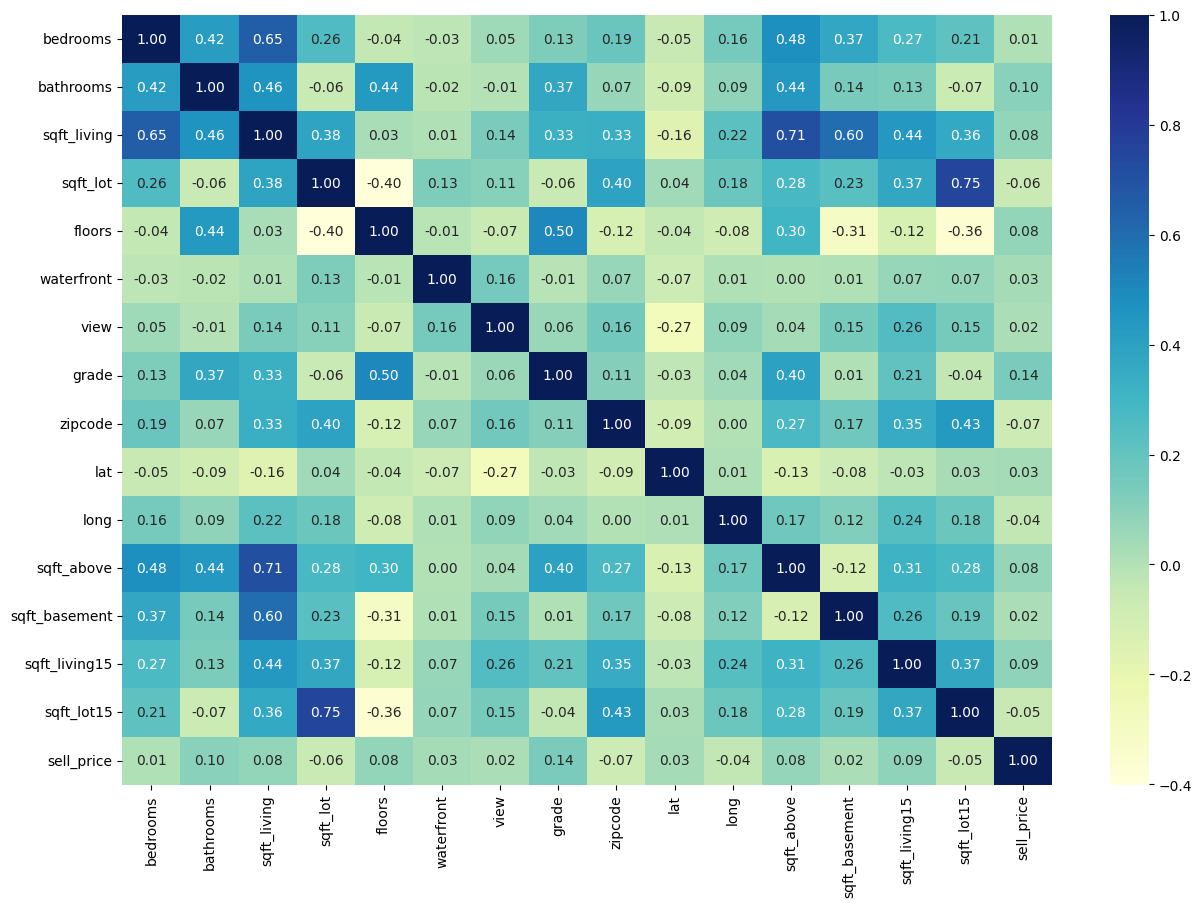

In [18]:
co_mtx = df_40_to_60[['bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','grade','zipcode','lat','long','sqft_above','sqft_basement','sqft_living15','sqft_lot15','sell_price']].corr(numeric_only=True)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(15, 10))
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True, fmt=".2f")
mplcursors.cursor(hover=True)

# Display heatmap
plt.show()